# **FORECASTTING PROJECT:** Random Forrest

In [3]:
import os
os.environ["KAGGLEHUB_CACHE"] = "/Users/mougouman/Desktop/Université/M2/S1/Forcecasting/Final Project"

### **Downloading dataset from Kaggle**

In [4]:
import pandas as pd
import os
import kagglehub

# Download latest version
path = kagglehub.dataset_download("averkiyoliabev/home-equity-line-of-creditheloc")

print("Path to dataset files:", path)

Path to dataset files: /Users/mougouman/Desktop/Université/M2/S1/Forcecasting/Final Project/datasets/averkiyoliabev/home-equity-line-of-creditheloc/versions/1


### **Importing Dataset with panda's CSV reader**

In [5]:
df = pd.read_csv(os.path.join(path, "heloc_dataset_v1.csv"))

df.head()

,RiskPerformance,ExternalRiskEstimate,MSinceOldestTradeOpen,MSinceMostRecentTradeOpen,AverageMInFile,NumSatisfactoryTrades,NumTrades60Ever2DerogPubRec,NumTrades90Ever2DerogPubRec,PercentTradesNeverDelq,MSinceMostRecentDelq,...,PercentInstallTrades,MSinceMostRecentInqexcl7days,NumInqLast6M,NumInqLast6Mexcl7days,NetFractionRevolvingBurden,NetFractionInstallBurden,NumRevolvingTradesWBalance,NumInstallTradesWBalance,NumBank2NatlTradesWHighUtilization,PercentTradesWBalance
0,Bad,55,144,4,84,20,3,0,83,2,...,43,0,0,0,33,-8,8,1,1,69
1,Bad,61,58,15,41,2,4,4,100,-7,...,67,0,0,0,0,-8,0,-8,-8,0
2,Bad,67,66,5,24,9,0,0,100,-7,...,44,0,4,4,53,66,4,2,1,86
3,Bad,66,169,1,73,28,1,1,93,76,...,57,0,5,4,72,83,6,4,3,91
4,Bad,81,333,27,132,12,0,0,100,-7,...,25,0,1,1,51,89,3,1,0,80


In [6]:
df["RiskPerformance"].value_counts()

RiskPerformance
Bad     5459
Good    5000
Name: count, dtype: int64

### **Turning "Good" and "Bad" into booleans**

In [7]:
df["RiskPerformance"] = df["RiskPerformance"].map({"Good": 1, "Bad": 0})


In [8]:
X = df.drop("RiskPerformance", axis=1)
y = df["RiskPerformance"]


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


In [23]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    min_samples_leaf=4,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=20, min_samples_leaf=4, n_estimators=200,
                       n_jobs=-1, random_state=42)

### **Accuracy and scores**

In [24]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.7246653919694073
              precision    recall  f1-score   support

           0       0.72      0.79      0.75      1638
           1       0.74      0.66      0.70      1500

    accuracy                           0.72      3138
   macro avg       0.73      0.72      0.72      3138
weighted avg       0.73      0.72      0.72      3138

[[1286  352]
 [ 512  988]]


### **Finding the best hyperparameters using RandomizedSearchCV**

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
import numpy as np

rf = RandomForestClassifier(random_state=42, n_jobs=-1)

param_dist = {
    "n_estimators": [200, 400, 600, 800],
    "max_depth": [5, 10, 20, 30, None],
    "max_features": ["sqrt", "log2", None],
    "min_samples_leaf": [1, 2, 4, 8]
}

rs = RandomizedSearchCV(
    rf,
    param_dist,
    n_iter=50,  #number of combinations of Random Forest hyperparameters to try
    scoring="accuracy",
    cv=5,
    random_state=42,
    n_jobs=-1
)

rs.fit(X_train, y_train)

print("Best params:", rs.best_params_)
print("Best CV accuracy:", rs.best_score_)


Best params: {'n_estimators': 200, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 20}
Best CV accuracy: 0.7225790298215184


### **SHAP Analysis**

In [ ]:
import shap

best_rf = rs.best_estimator_
explainer = shap.TreeExplainer(best_rf)

shap_values = explainer(X_test)



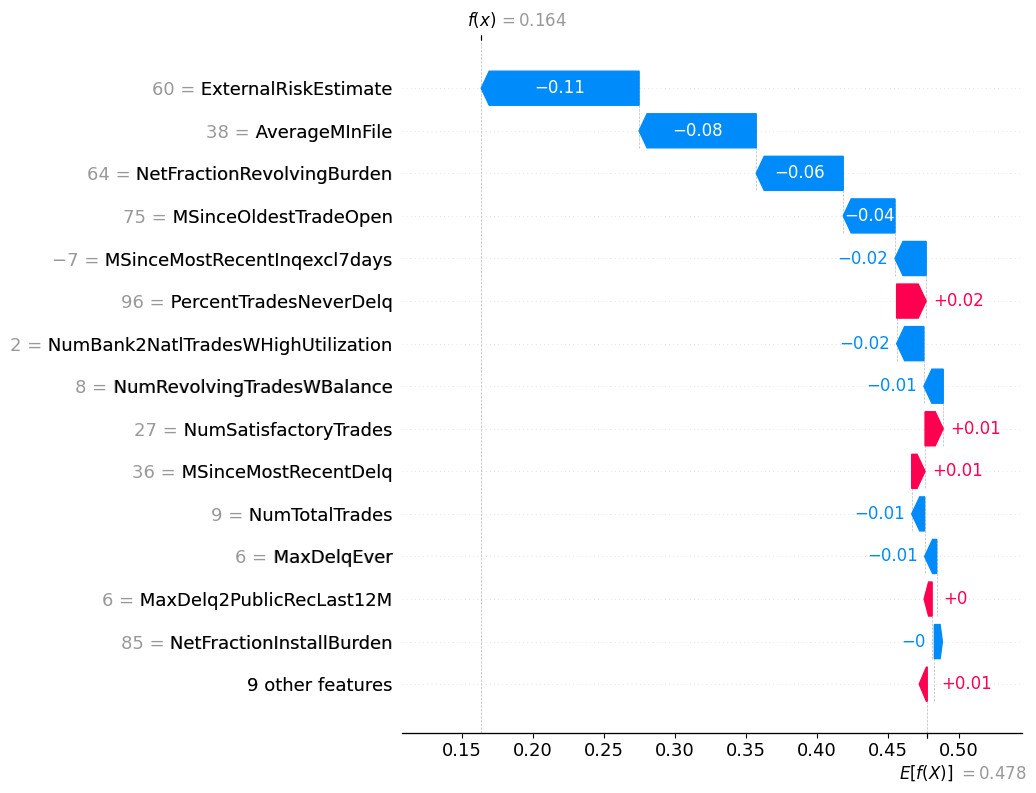

In [ ]:
i = 0 
shap.plots.waterfall(shap_values[i, :, 1], max_display=15)
